# Notebook 2 — EDA & Behavioral Visualizations
**Նպատակ:** Binance BTCUSDT տվյալների խորը վերլուծություն և վիզուալիզացիա  
**Ուսումնասիրում ենք:** Order flow, trade size behavior, trading intensity, market microstructure

## 1. Libraries & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
os_sep = '/'

import os
os.makedirs('data/eda', exist_ok=True)

df = pd.read_pickle('data/processed/trades_clean.pkl')
print(f'Loaded: {len(df):,} trades')
print(f'Period: {df["time"].min()} → {df["time"].max()}')
df.head(3)

Loaded: 20,106,683 trades
Period: 2024-01-01 00:00:00 → 2024-01-10 23:59:59.999000


,trade_id,price,qty,quote_qty,time,is_buyer_maker,is_best_match,side,date,hour,month
0,3344774379,42283.58,0.00069,29.175670,2024-01-01 00:00:00.000,True,True,sell,2024-01-01,0,2024-01
1,3344774380,42283.59,0.00144,60.888370,2024-01-01 00:00:00.001,False,True,buy,2024-01-01,0,2024-01
2,3344774381,42283.58,0.00102,43.129252,2024-01-01 00:00:00.003,True,True,sell,2024-01-01,0,2024-01


## 2. 1-Minute Aggregation
Tick-level տվյալները aggregate ենք անում 1-րոպեի granularity-ով — neural network-ի input-ի հիմք։

In [6]:
df['buy_qty']  = df['qty'].where(df['side'] == 'buy', 0)
df['sell_qty'] = df['qty'].where(df['side'] == 'sell', 0)
df['pv']       = df['price'] * df['qty']

df_indexed = df.set_index('time')

df_1min = df_indexed.resample('1min').agg(
    open_price     = ('price',     'first'),
    close_price    = ('price',     'last'),
    high           = ('price',     'max'),
    low            = ('price',     'min'),
    total_volume   = ('qty',       'sum'),
    total_quote    = ('quote_qty', 'sum'),
    trade_count    = ('trade_id',  'count'),
    avg_trade_size = ('qty',       'mean'),
    buy_count      = ('side',      lambda x: (x == 'buy').sum()),
    sell_count     = ('side',      lambda x: (x == 'sell').sum()),
    buy_volume     = ('buy_qty',   'sum'),
    sell_volume    = ('sell_qty',  'sum'),
    pv_sum         = ('pv',        'sum'),
).dropna(subset=['open_price'])

# VWAP
df_1min['vwap'] = df_1min['pv_sum'] / (df_1min['total_volume'] + 1e-9)
df_1min = df_1min.drop(columns=['pv_sum'])

# Large trade count
large_threshold = df['qty'].quantile(0.95)
df_1min['large_trade_count'] = (df_indexed['qty']
                                 .resample('1min')
                                 .apply(lambda x: (x > large_threshold).sum()))

# Derived features
df_1min['price_return']    = df_1min['close_price'].pct_change()
df_1min['log_return']      = np.log(df_1min['close_price'] / df_1min['close_price'].shift(1))
df_1min['ofi']             = df_1min['buy_volume'] - df_1min['sell_volume']
df_1min['ofi_ratio']       = df_1min['ofi'] / (df_1min['total_volume'] + 1e-9)
df_1min['buy_ratio']       = df_1min['buy_count'] / (df_1min['trade_count'] + 1e-9)
df_1min['volatility']      = df_1min['log_return'].rolling(30).std()
df_1min['volume_ma']       = df_1min['total_volume'].rolling(30).mean()
df_1min['volume_ratio']    = df_1min['total_volume'] / (df_1min['volume_ma'] + 1e-9)
df_1min['price_range']     = (df_1min['high'] - df_1min['low']) / df_1min['open_price']
df_1min['trade_intensity'] = df_1min['trade_count'].rolling(10).mean()

df_1min = df_1min.dropna().reset_index()
print(f'1-min bars: {len(df_1min):,}')
print(f'Columns: {list(df_1min.columns)}')
df_1min.head(3)

1-min bars: 14,370
Columns: ['time', 'open_price', 'close_price', 'high', 'low', 'total_volume', 'total_quote', 'trade_count', 'avg_trade_size', 'buy_count', 'sell_count', 'buy_volume', 'sell_volume', 'vwap', 'large_trade_count', 'price_return', 'log_return', 'ofi', 'ofi_ratio', 'buy_ratio', 'volatility', 'volume_ma', 'volume_ratio', 'price_range', 'trade_intensity']


,time,open_price,close_price,high,low,total_volume,total_quote,trade_count,avg_trade_size,buy_count,...,price_return,log_return,ofi,ofi_ratio,buy_ratio,volatility,volume_ma,volume_ratio,price_range,trade_intensity
0,2024-01-01 00:30:00,42419.73,42391.51,42419.73,42391.34,18.10354,767713.700815,1138,0.015908,373,...,-0.000665,-0.000665,-9.56316,-0.528248,0.327768,0.000533,26.871200,0.673715,0.000669,781.2
1,2024-01-01 00:31:00,42391.51,42381.99,42391.51,42377.64,12.99361,550679.078181,804,0.016161,333,...,-0.000225,-0.000225,-3.35125,-0.257915,0.414179,0.000530,26.598728,0.488505,0.000327,783.9
2,2024-01-01 00:32:00,42382.00,42373.11,42399.99,42373.11,13.11311,555887.280311,978,0.013408,376,...,-0.000210,-0.000210,-1.76251,-0.134408,0.384458,0.000532,26.315701,0.498300,0.000634,814.5


## 3. Price & Volume Overview

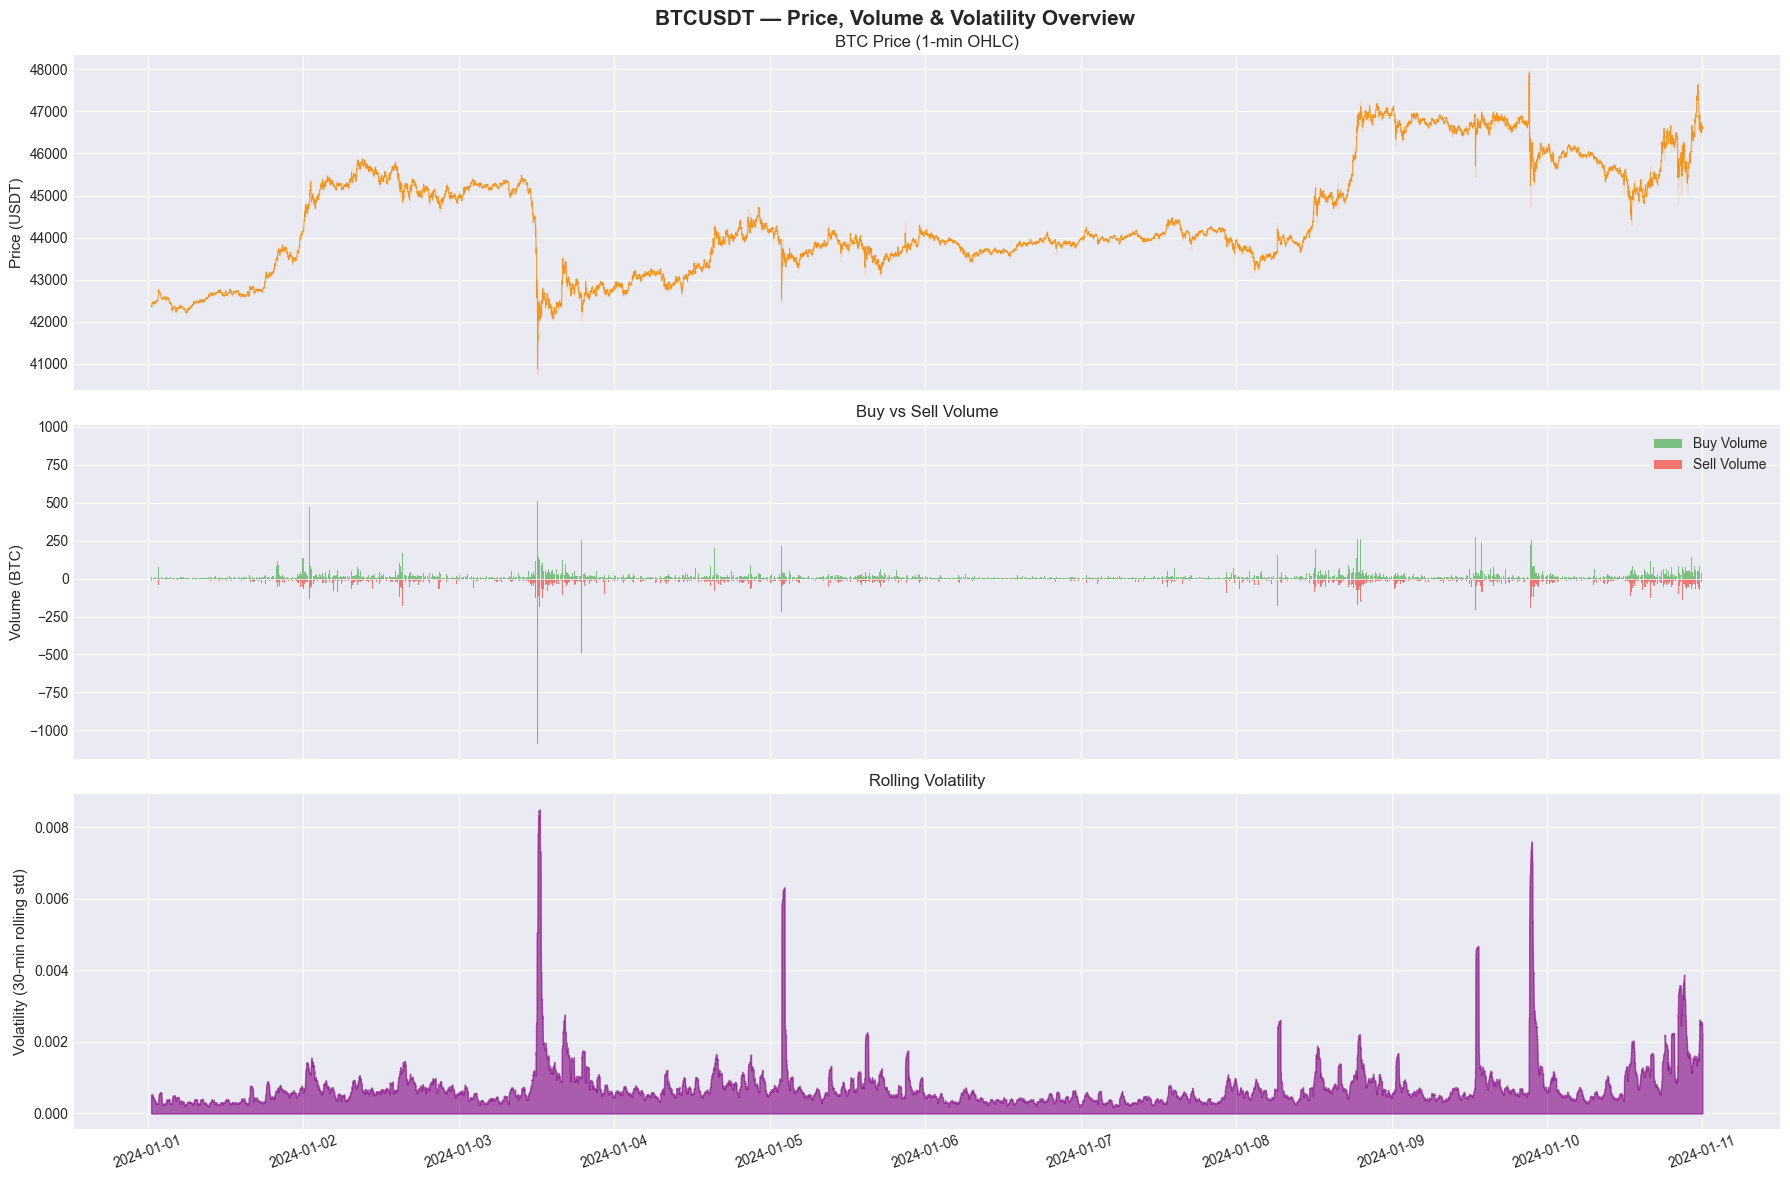

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
fig.suptitle('BTCUSDT — Price, Volume & Volatility Overview', fontsize=15, fontweight='bold')

# Price
axes[0].plot(df_1min['time'], df_1min['close_price'], color='#F7931A', linewidth=0.6)
axes[0].fill_between(df_1min['time'], df_1min['low'], df_1min['high'], alpha=0.15, color='#F7931A')
axes[0].set_ylabel('Price (USDT)', fontsize=11)
axes[0].set_title('BTC Price (1-min OHLC)', fontsize=12)

# Volume
buy_vol  = df_1min['buy_volume']
sell_vol = df_1min['sell_volume']
axes[1].bar(df_1min['time'], buy_vol,  color='#4CAF50', alpha=0.7, width=0.0006, label='Buy Volume')
axes[1].bar(df_1min['time'], -sell_vol, color='#F44336', alpha=0.7, width=0.0006, label='Sell Volume')
axes[1].axhline(0, color='white', linewidth=0.5)
axes[1].set_ylabel('Volume (BTC)', fontsize=11)
axes[1].set_title('Buy vs Sell Volume', fontsize=12)
axes[1].legend(loc='upper right')

# Volatility
axes[2].fill_between(df_1min['time'], df_1min['volatility'], alpha=0.6, color='purple')
axes[2].set_ylabel('Volatility (30-min rolling std)', fontsize=11)
axes[2].set_title('Rolling Volatility', fontsize=12)
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('data/eda/02_price_volume_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Order Flow Imbalance (OFI) Analysis
**Ենթահարց 1:** Ինչպե՞ս է buy/sell imbalance-ը կանխատեսում գնի շարժումը։

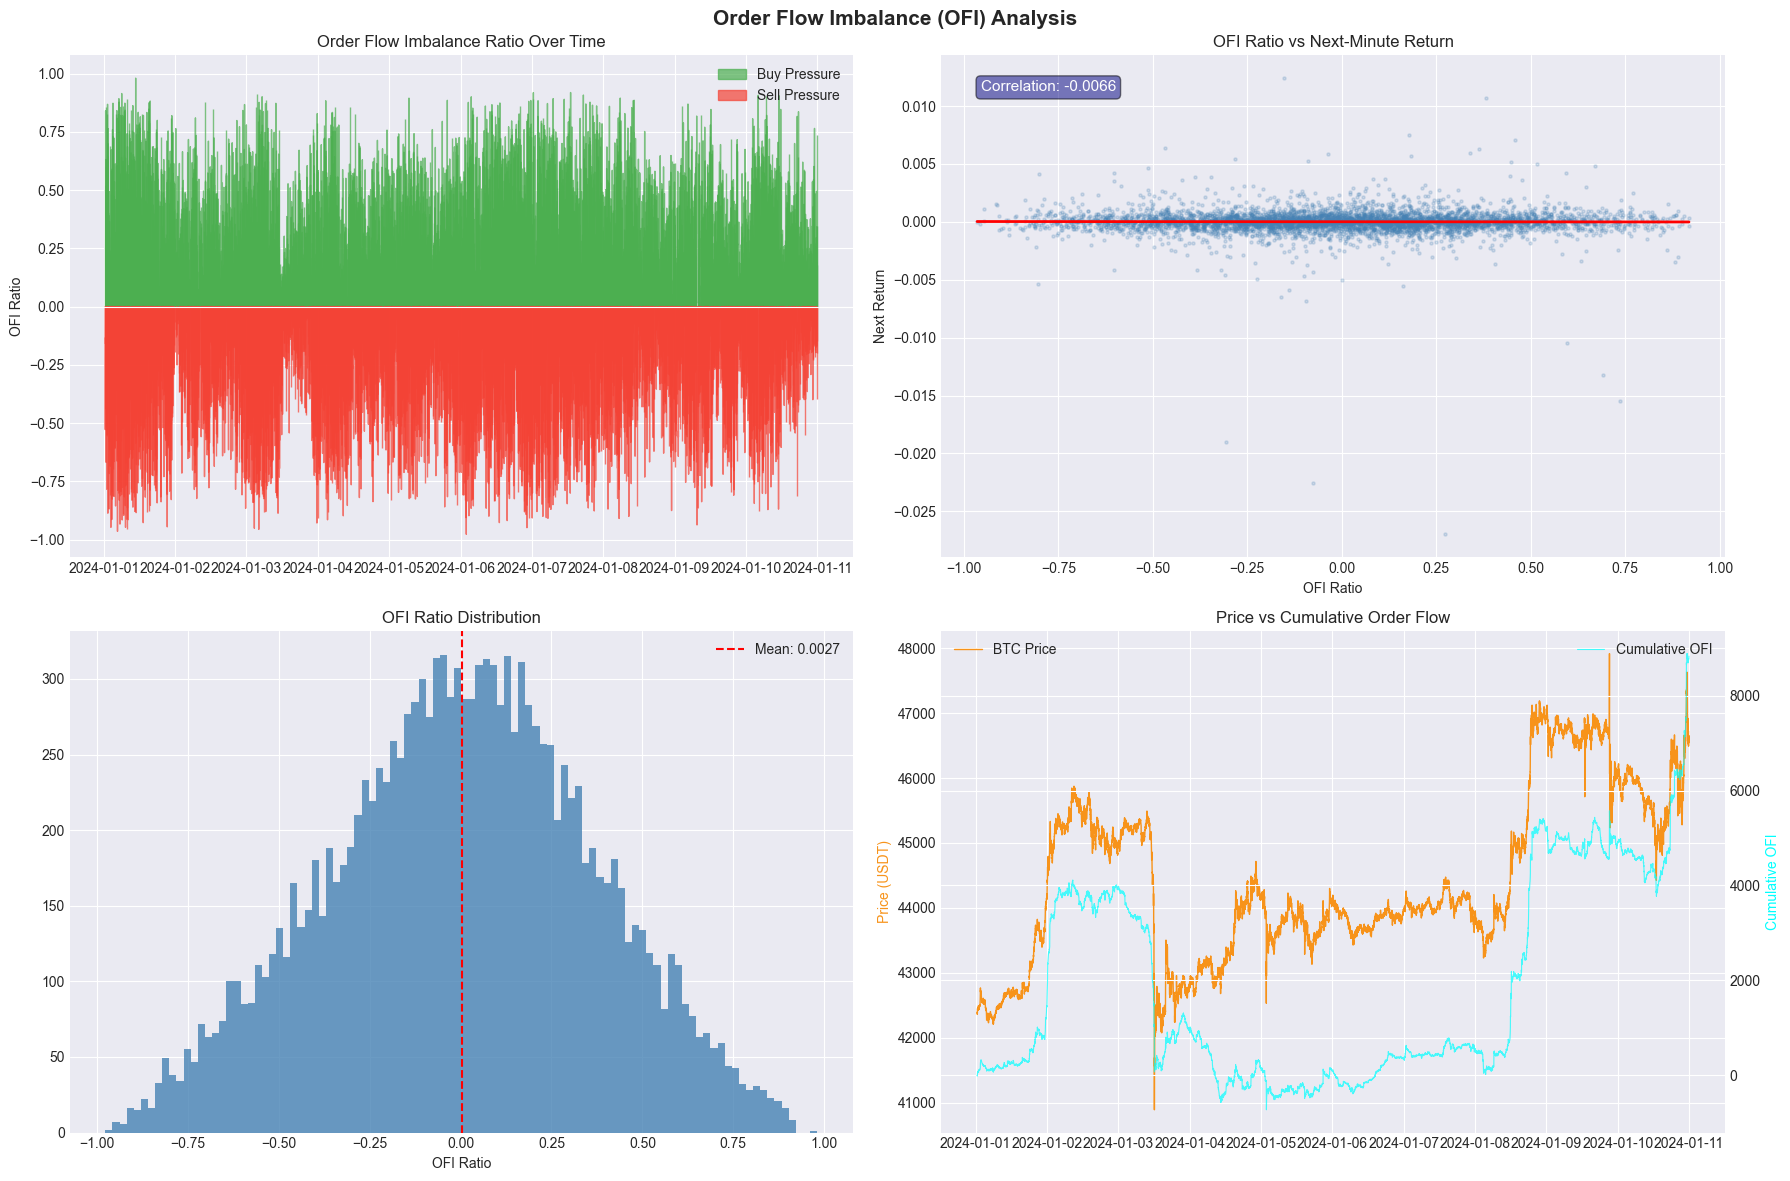

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Order Flow Imbalance (OFI) Analysis', fontsize=15, fontweight='bold')

# 1. OFI over time
axes[0,0].fill_between(df_1min['time'],
    df_1min['ofi_ratio'],
    where=df_1min['ofi_ratio'] > 0, alpha=0.7, color='#4CAF50', label='Buy Pressure')
axes[0,0].fill_between(df_1min['time'],
    df_1min['ofi_ratio'],
    where=df_1min['ofi_ratio'] <= 0, alpha=0.7, color='#F44336', label='Sell Pressure')
axes[0,0].axhline(0, color='white', linewidth=0.8)
axes[0,0].set_title('Order Flow Imbalance Ratio Over Time')
axes[0,0].set_ylabel('OFI Ratio')
axes[0,0].legend()

# 2. OFI vs Next Return (scatter)
sample = df_1min.sample(min(5000, len(df_1min)), random_state=42)
axes[0,1].scatter(sample['ofi_ratio'], sample['price_return'].shift(-1),
                  alpha=0.2, s=5, color='steelblue')
# Regression line
mask = sample['price_return'].shift(-1).notna()
x = sample['ofi_ratio'][mask]
y = sample['price_return'].shift(-1)[mask]
m, b = np.polyfit(x, y, 1)
axes[0,1].plot(np.sort(x), m*np.sort(x)+b, color='red', linewidth=2)
axes[0,1].set_title('OFI Ratio vs Next-Minute Return')
axes[0,1].set_xlabel('OFI Ratio')
axes[0,1].set_ylabel('Next Return')
corr = x.corr(y)
axes[0,1].text(0.05, 0.95, f'Correlation: {corr:.4f}',
               transform=axes[0,1].transAxes, fontsize=11,
               verticalalignment='top', color='white',
               bbox=dict(boxstyle='round', facecolor='navy', alpha=0.5))

# 3. OFI distribution
axes[1,0].hist(df_1min['ofi_ratio'], bins=100, color='steelblue', alpha=0.8, edgecolor='none')
axes[1,0].axvline(df_1min['ofi_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {df_1min["ofi_ratio"].mean():.4f}')
axes[1,0].set_title('OFI Ratio Distribution')
axes[1,0].set_xlabel('OFI Ratio')
axes[1,0].legend()

# 4. Cumulative OFI vs Price
ax4a = axes[1,1]
ax4b = ax4a.twinx()
cum_ofi = df_1min['ofi'].cumsum()
ax4a.plot(df_1min['time'], df_1min['close_price'], color='#F7931A', linewidth=1, label='BTC Price')
ax4b.plot(df_1min['time'], cum_ofi, color='cyan', linewidth=0.8, alpha=0.7, label='Cumulative OFI')
ax4a.set_ylabel('Price (USDT)', color='#F7931A')
ax4b.set_ylabel('Cumulative OFI', color='cyan')
axes[1,1].set_title('Price vs Cumulative Order Flow')
ax4a.legend(loc='upper left')
ax4b.legend(loc='upper right')

plt.tight_layout()
plt.savefig('data/eda/03_order_flow_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Trade Size Behavior
**Ենթահարց 2:** Մեծ trade-երի ազդեցությունը գնի վրա։

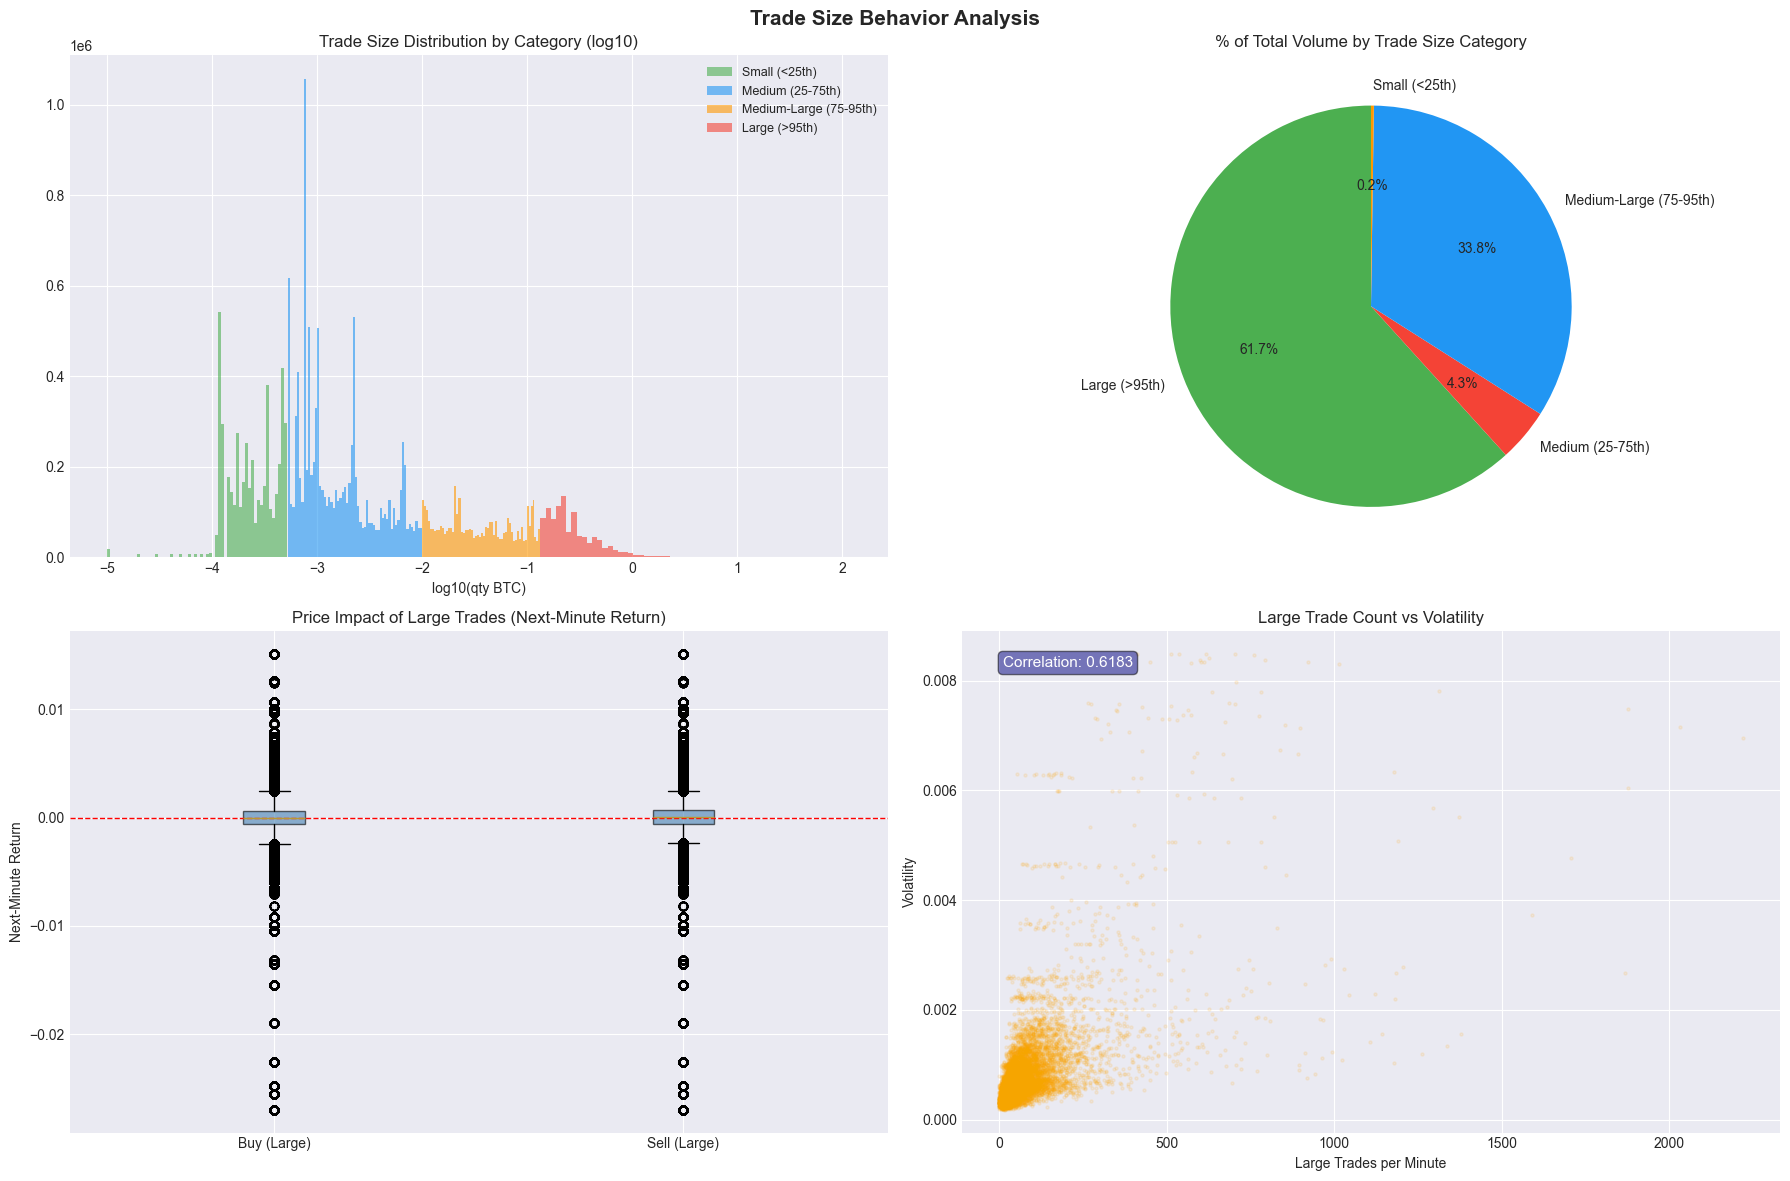

In [9]:
# Classify trades by size
q25 = df['qty'].quantile(0.25)
q75 = df['qty'].quantile(0.75)
q95 = df['qty'].quantile(0.95)

def classify_trade(qty):
    if qty >= q95:   return 'Large (>95th)'
    elif qty >= q75: return 'Medium-Large (75-95th)'
    elif qty >= q25: return 'Medium (25-75th)'
    else:            return 'Small (<25th)'

df['size_category'] = df['qty'].apply(classify_trade)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Trade Size Behavior Analysis', fontsize=15, fontweight='bold')

# 1. Trade size distribution (log)
for cat, color in zip(['Small (<25th)', 'Medium (25-75th)', 'Medium-Large (75-95th)', 'Large (>95th)'],
                       ['#4CAF50', '#2196F3', '#FF9800', '#F44336']):
    subset = df[df['size_category']==cat]['qty']
    axes[0,0].hist(np.log10(subset+1e-9), bins=60, alpha=0.6, label=cat, color=color)
axes[0,0].set_title('Trade Size Distribution by Category (log10)')
axes[0,0].set_xlabel('log10(qty BTC)')
axes[0,0].legend(fontsize=9)

# 2. Large trades % of total volume
size_vol = df.groupby('size_category')['quote_qty'].sum()
size_vol_pct = size_vol / size_vol.sum() * 100
colors_pie = ['#4CAF50', '#F44336', '#2196F3', '#FF9800']
axes[0,1].pie(size_vol_pct, labels=size_vol_pct.index,
              autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[0,1].set_title('% of Total Volume by Trade Size Category')

# 3. Avg price impact by trade size (1-min return after large trade)
# Merge tick data with 1-min returns
df_large = df[df['size_category']=='Large (>95th)'].copy()
df_large['minute'] = df_large['time'].dt.floor('1min')
df_1min_idx = df_1min.set_index('time')
df_large['next_return'] = df_large['minute'].map(
    df_1min_idx['price_return'].shift(-1))
df_large['buy_impact'] = df_large.apply(
    lambda r: r['next_return'] if r['side']=='buy' else -r['next_return'], axis=1)

# Compare buy vs sell large trade impact
impact_data = {
    'Buy (Large)': df_large[df_large['side']=='buy']['next_return'].dropna(),
    'Sell (Large)': df_large[df_large['side']=='sell']['next_return'].dropna()
}
axes[1,0].boxplot([impact_data['Buy (Large)'], impact_data['Sell (Large)']],
                  labels=['Buy (Large)', 'Sell (Large)'],
                  patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1,0].set_title('Price Impact of Large Trades (Next-Minute Return)')
axes[1,0].set_ylabel('Next-Minute Return')

# 4. Large trade count vs volatility
axes[1,1].scatter(df_1min['large_trade_count'], df_1min['volatility'],
                  alpha=0.1, s=5, color='orange')
axes[1,1].set_title('Large Trade Count vs Volatility')
axes[1,1].set_xlabel('Large Trades per Minute')
axes[1,1].set_ylabel('Volatility')
corr2 = df_1min['large_trade_count'].corr(df_1min['volatility'])
axes[1,1].text(0.05, 0.95, f'Correlation: {corr2:.4f}',
               transform=axes[1,1].transAxes, fontsize=11,
               verticalalignment='top', color='white',
               bbox=dict(boxstyle='round', facecolor='navy', alpha=0.5))

plt.tight_layout()
plt.savefig('data/eda/04_trade_size_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Trading Intensity & Seasonality
**Ենթահարց 3:** Trading bursts, frequency և seasonality։

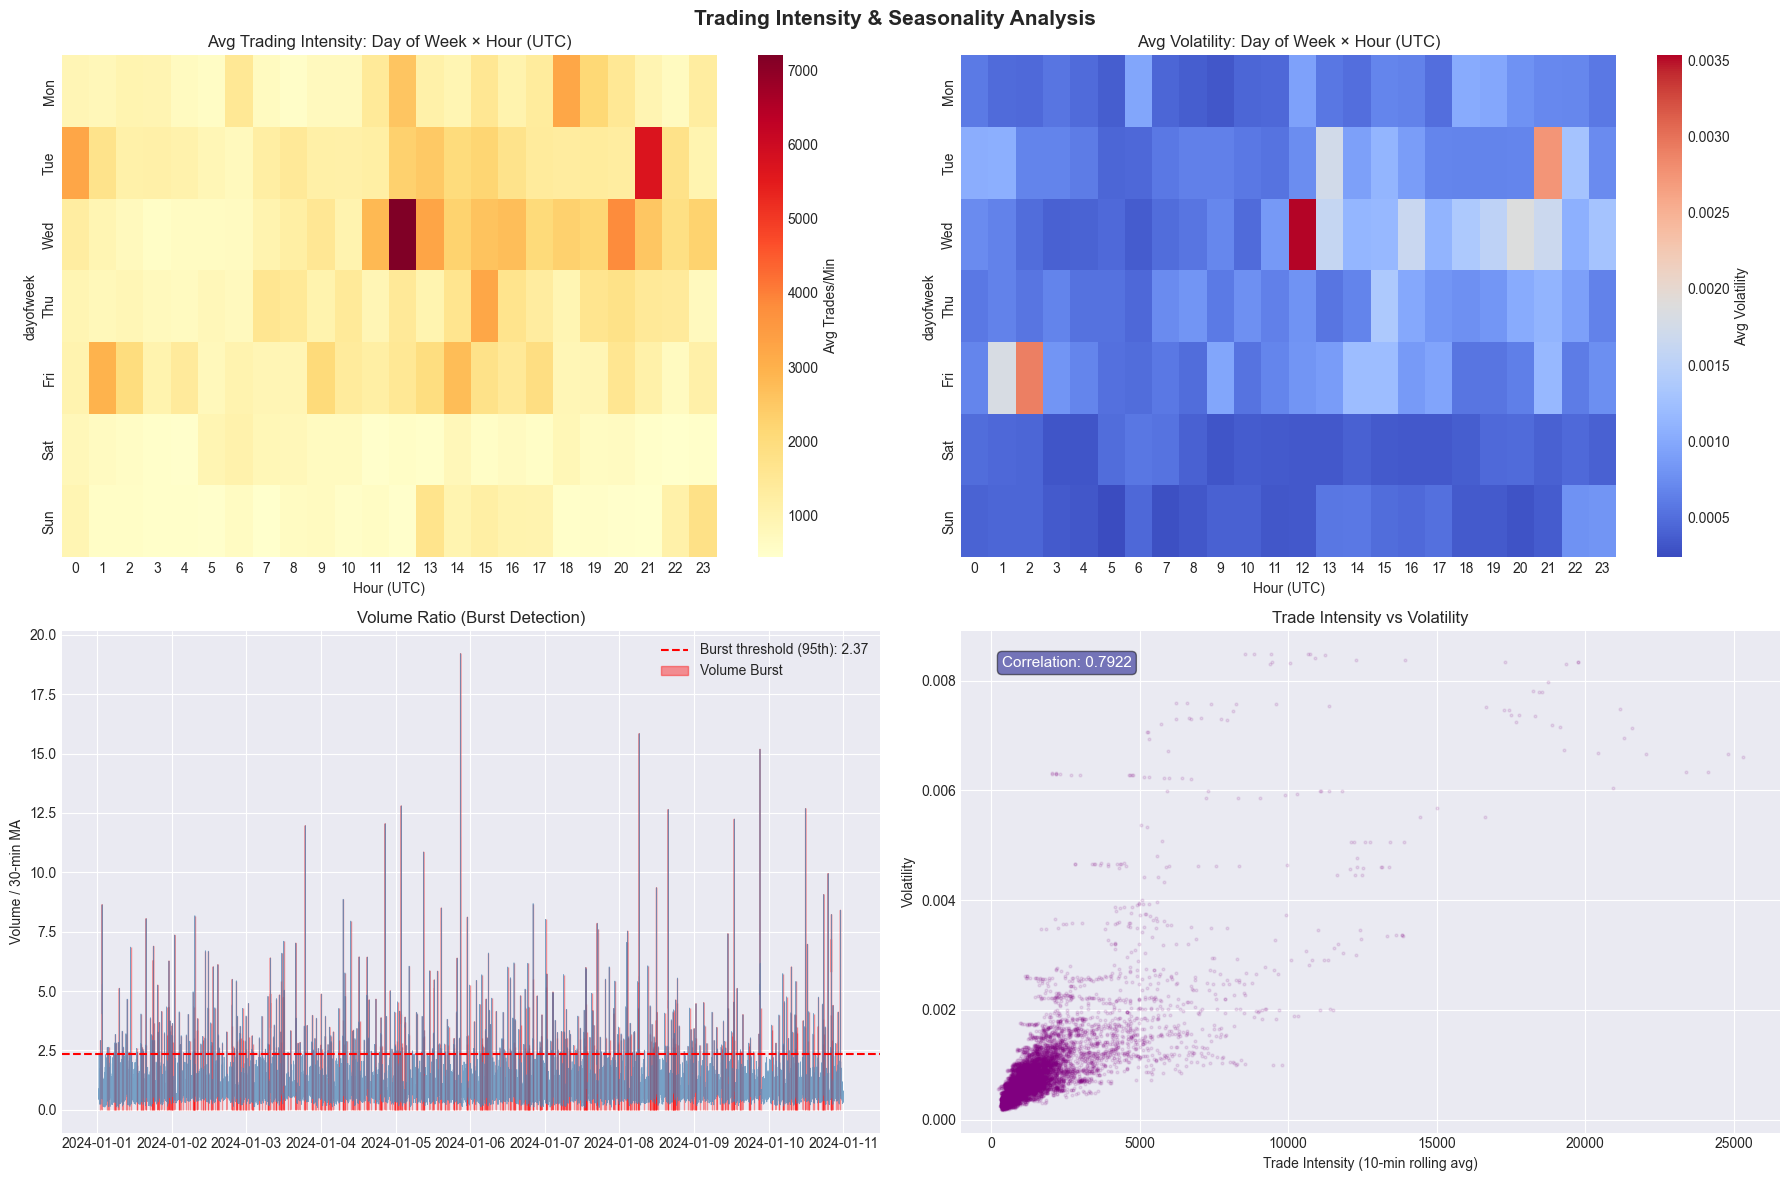

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Trading Intensity & Seasonality Analysis', fontsize=15, fontweight='bold')

# 1. Intraday trade count heatmap (hour x day of week)
df_1min['hour'] = df_1min['time'].dt.hour
df_1min['dayofweek'] = df_1min['time'].dt.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot_intensity = df_1min.groupby(['dayofweek', 'hour'])['trade_count'].mean().unstack()
sns.heatmap(pivot_intensity, ax=axes[0,0], cmap='YlOrRd',
            yticklabels=day_names, cbar_kws={'label': 'Avg Trades/Min'})
axes[0,0].set_title('Avg Trading Intensity: Day of Week × Hour (UTC)')
axes[0,0].set_xlabel('Hour (UTC)')

# 2. Volatility heatmap (same structure)
pivot_vol = df_1min.groupby(['dayofweek', 'hour'])['volatility'].mean().unstack()
sns.heatmap(pivot_vol, ax=axes[0,1], cmap='coolwarm',
            yticklabels=day_names, cbar_kws={'label': 'Avg Volatility'})
axes[0,1].set_title('Avg Volatility: Day of Week × Hour (UTC)')
axes[0,1].set_xlabel('Hour (UTC)')

# 3. Volume ratio (burst detection)
burst_threshold = df_1min['volume_ratio'].quantile(0.95)
is_burst = df_1min['volume_ratio'] >= burst_threshold
axes[1,0].plot(df_1min['time'], df_1min['volume_ratio'], color='steelblue', linewidth=0.5, alpha=0.7)
axes[1,0].axhline(burst_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Burst threshold (95th): {burst_threshold:.2f}')
axes[1,0].fill_between(df_1min['time'], df_1min['volume_ratio'],
                        where=is_burst, color='red', alpha=0.4, label='Volume Burst')
axes[1,0].set_title('Volume Ratio (Burst Detection)')
axes[1,0].set_ylabel('Volume / 30-min MA')
axes[1,0].legend()

# 4. Trade intensity vs volatility
axes[1,1].scatter(df_1min['trade_intensity'], df_1min['volatility'],
                  alpha=0.1, s=4, color='purple')
axes[1,1].set_title('Trade Intensity vs Volatility')
axes[1,1].set_xlabel('Trade Intensity (10-min rolling avg)')
axes[1,1].set_ylabel('Volatility')
corr3 = df_1min['trade_intensity'].corr(df_1min['volatility'])
axes[1,1].text(0.05, 0.95, f'Correlation: {corr3:.4f}',
               transform=axes[1,1].transAxes, fontsize=11,
               verticalalignment='top', color='white',
               bbox=dict(boxstyle='round', facecolor='navy', alpha=0.5))

plt.tight_layout()
plt.savefig('data/eda/05_trading_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Market Microstructure
**Ենթահարց 4:** is_buyer_maker, trade clustering, liquidity patterns։

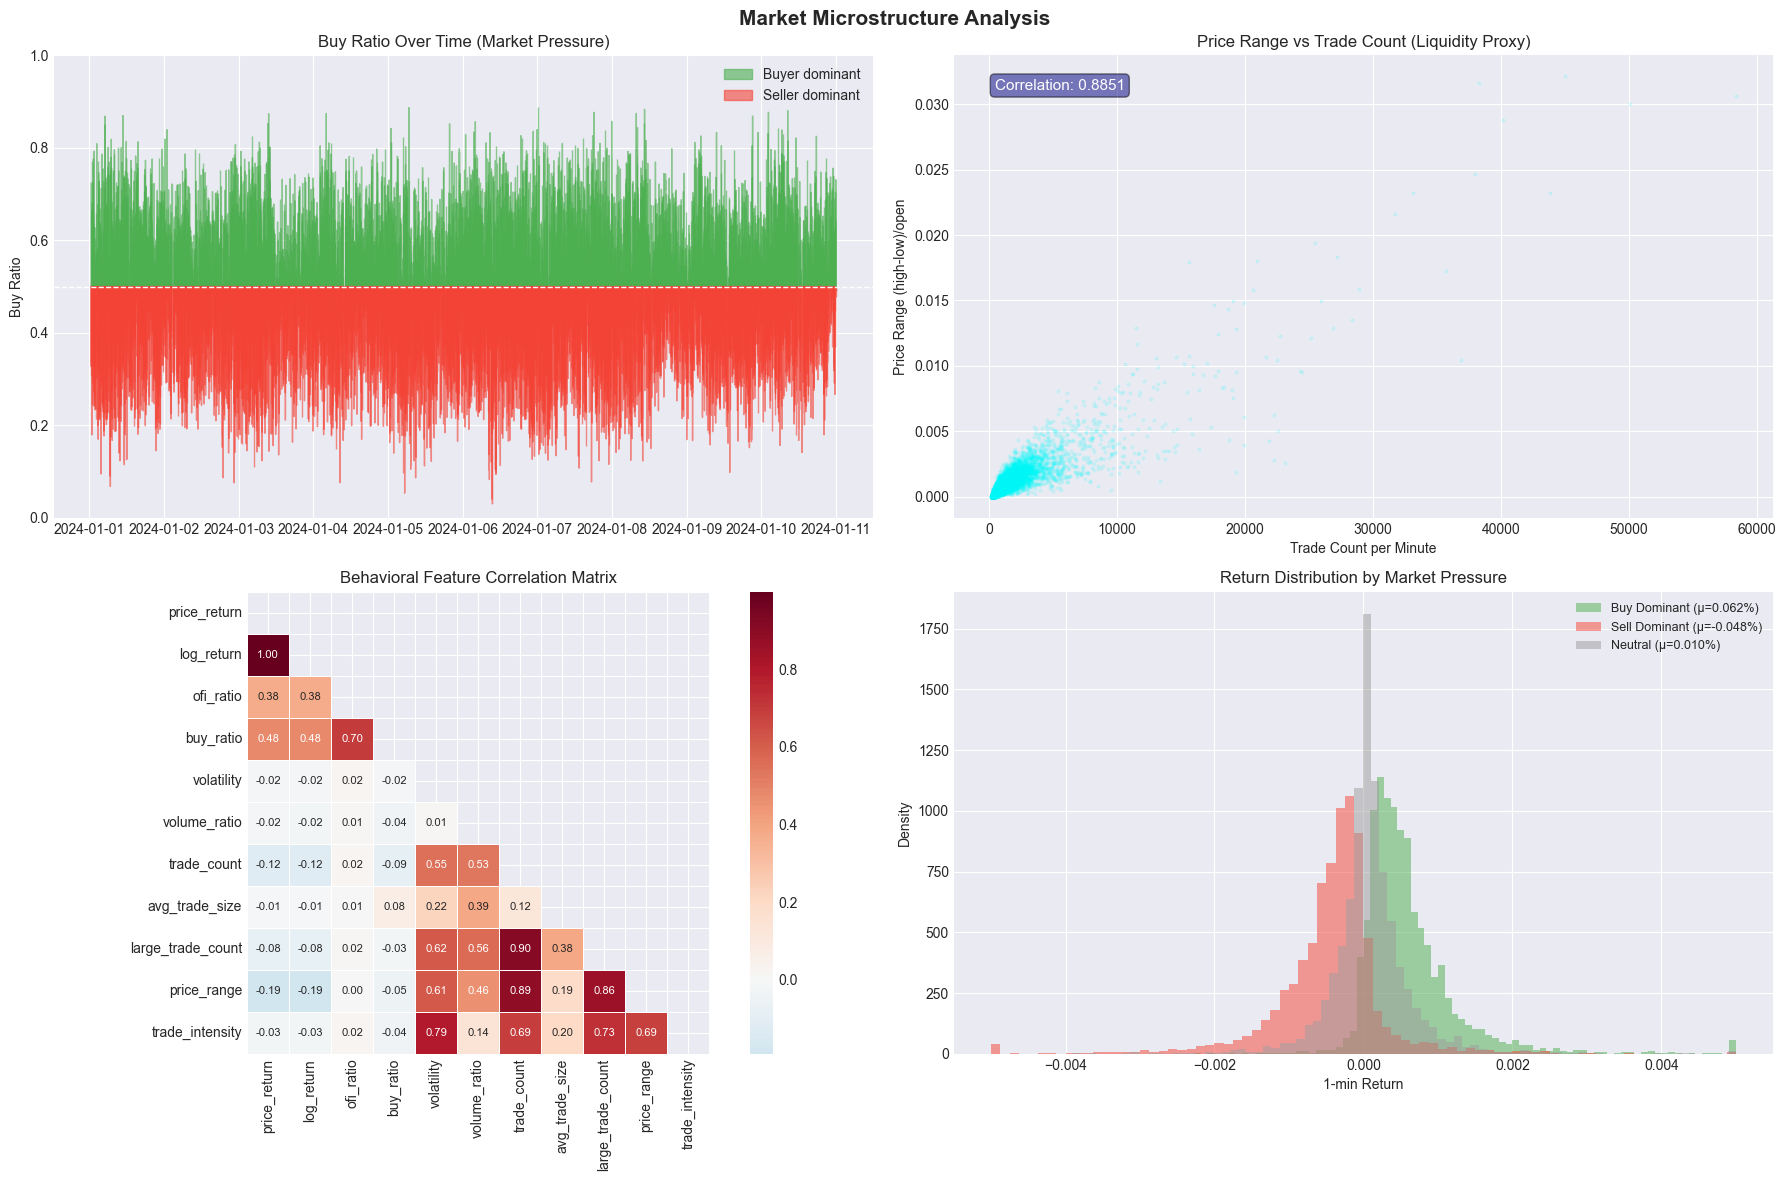

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Market Microstructure Analysis', fontsize=15, fontweight='bold')

# 1. is_buyer_maker ratio over time
maker_ratio = df_1min['buy_ratio']  # buy_count / trade_count
axes[0,0].fill_between(df_1min['time'], maker_ratio, 0.5,
    where=maker_ratio > 0.5, alpha=0.6, color='#4CAF50', label='Buyer dominant')
axes[0,0].fill_between(df_1min['time'], maker_ratio, 0.5,
    where=maker_ratio <= 0.5, alpha=0.6, color='#F44336', label='Seller dominant')
axes[0,0].axhline(0.5, color='white', linewidth=1, linestyle='--')
axes[0,0].set_title('Buy Ratio Over Time (Market Pressure)')
axes[0,0].set_ylabel('Buy Ratio')
axes[0,0].set_ylim(0, 1)
axes[0,0].legend()

# 2. Price range vs trade count (liquidity)
axes[0,1].scatter(df_1min['trade_count'], df_1min['price_range'],
                  alpha=0.1, s=4, color='cyan')
axes[0,1].set_title('Price Range vs Trade Count (Liquidity Proxy)')
axes[0,1].set_xlabel('Trade Count per Minute')
axes[0,1].set_ylabel('Price Range (high-low)/open')
corr4 = df_1min['trade_count'].corr(df_1min['price_range'])
axes[0,1].text(0.05, 0.95, f'Correlation: {corr4:.4f}',
               transform=axes[0,1].transAxes, fontsize=11,
               verticalalignment='top', color='white',
               bbox=dict(boxstyle='round', facecolor='navy', alpha=0.5))

# 3. Correlation matrix of all behavioral features
feature_cols = ['price_return', 'log_return', 'ofi_ratio', 'buy_ratio',
                'volatility', 'volume_ratio', 'trade_count',
                'avg_trade_size', 'large_trade_count', 'price_range', 'trade_intensity']
corr_matrix = df_1min[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[1,0], mask=mask, cmap='RdBu_r',
            center=0, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True, linewidths=0.5)
axes[1,0].set_title('Behavioral Feature Correlation Matrix')

# 4. Return distribution: buyer-maker vs seller-maker
buy_dominant  = df_1min[df_1min['buy_ratio'] > 0.55]['price_return'].dropna()
sell_dominant = df_1min[df_1min['buy_ratio'] < 0.45]['price_return'].dropna()
neutral       = df_1min[(df_1min['buy_ratio'] >= 0.45) & (df_1min['buy_ratio'] <= 0.55)]['price_return'].dropna()

for data, label, color in [(buy_dominant, 'Buy Dominant', '#4CAF50'),
                            (sell_dominant, 'Sell Dominant', '#F44336'),
                            (neutral, 'Neutral', '#9E9E9E')]:
    axes[1,1].hist(data.clip(-0.005, 0.005), bins=80, alpha=0.5,
                   label=f'{label} (μ={data.mean()*100:.3f}%)', color=color, density=True)
axes[1,1].set_title('Return Distribution by Market Pressure')
axes[1,1].set_xlabel('1-min Return')
axes[1,1].set_ylabel('Density')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('data/eda/06_microstructure.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Regime Detection Preview
**Ենթահարց 5:** Շուկայական ռեժիմների նախնական հայտնաբերում։

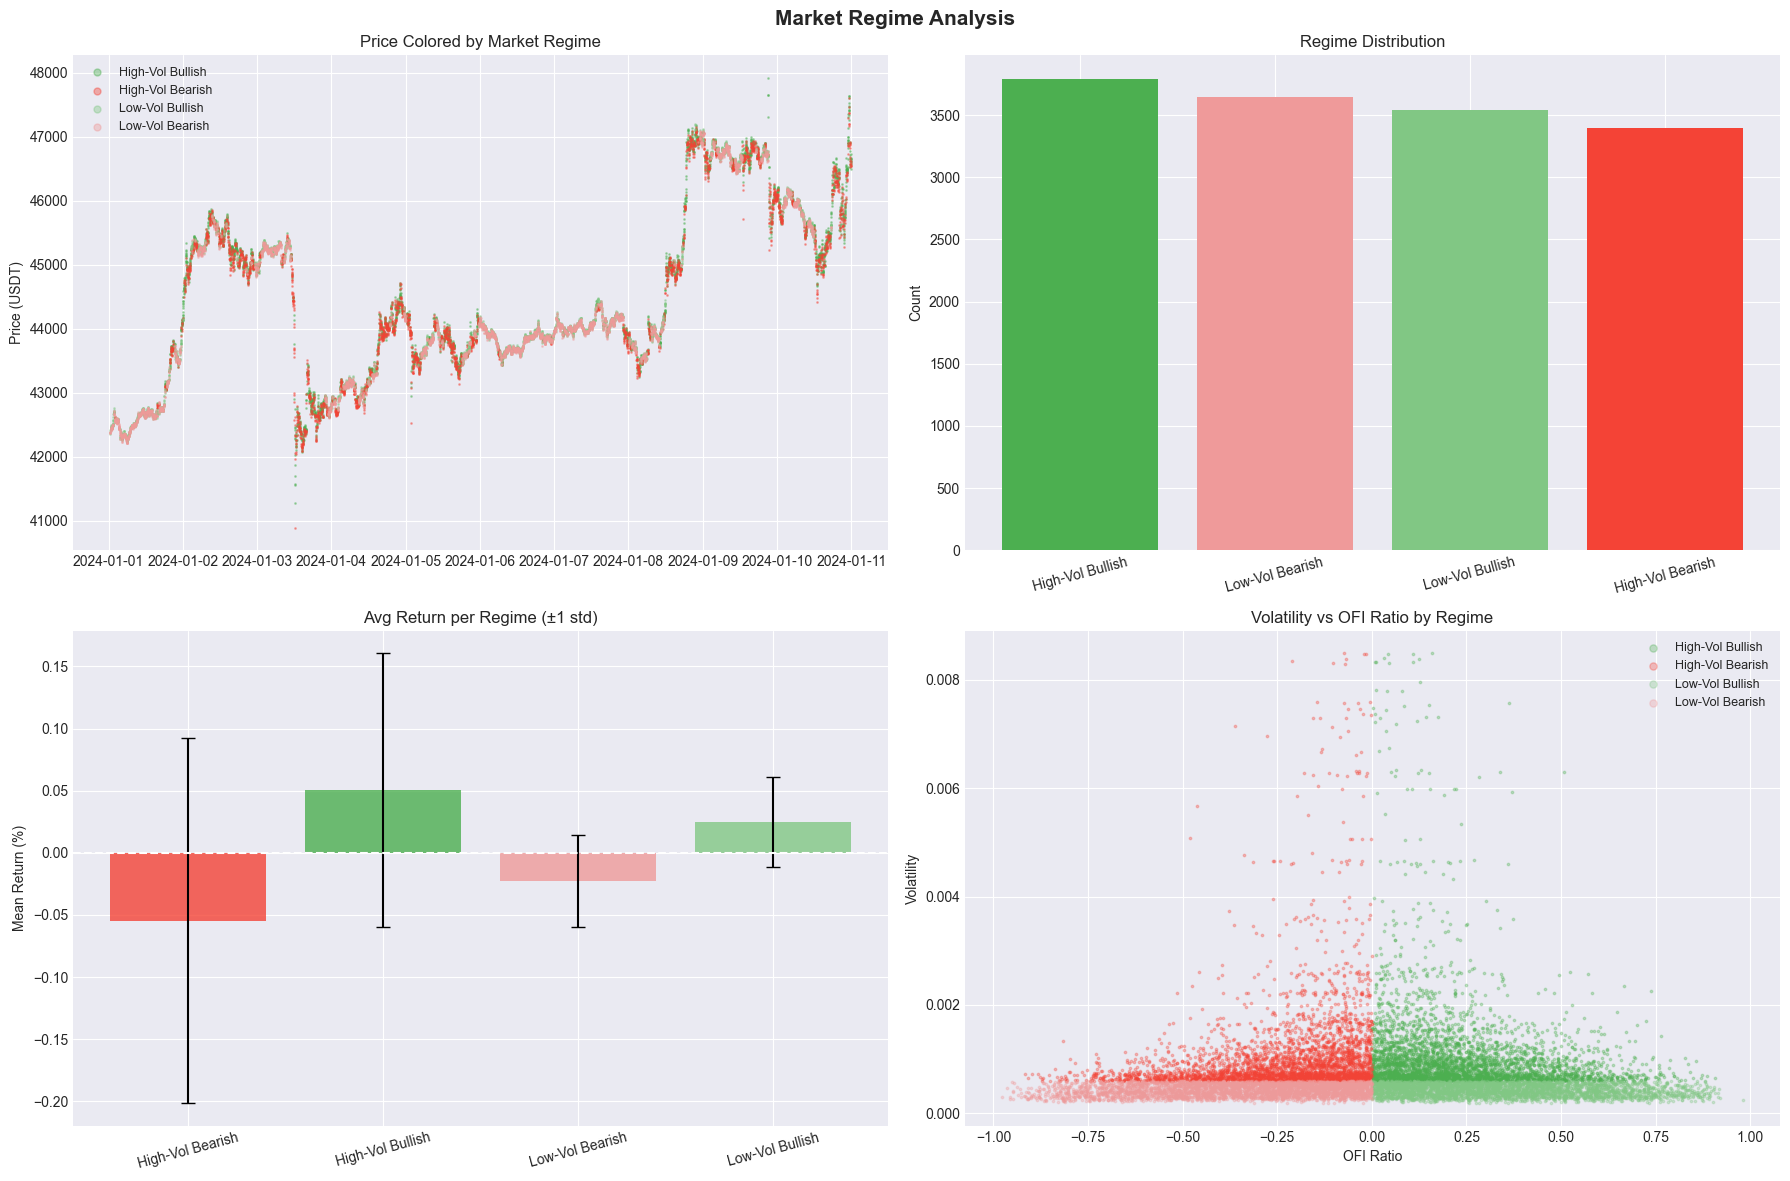

In [12]:
# Simple regime classification based on volatility and OFI
vol_median = df_1min['volatility'].median()
ofi_zero   = 0

def classify_regime(row):
    high_vol = row['volatility'] > vol_median
    buy_pres  = row['ofi_ratio'] > ofi_zero
    if high_vol and buy_pres:   return 'High-Vol Bullish'
    if high_vol and not buy_pres: return 'High-Vol Bearish'
    if not high_vol and buy_pres: return 'Low-Vol Bullish'
    return 'Low-Vol Bearish'

df_1min['regime'] = df_1min.apply(classify_regime, axis=1)

regime_colors = {
    'High-Vol Bullish': '#4CAF50',
    'High-Vol Bearish': '#F44336',
    'Low-Vol Bullish':  '#81C784',
    'Low-Vol Bearish':  '#EF9A9A',
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Market Regime Analysis', fontsize=15, fontweight='bold')

# 1. Price colored by regime
for regime, color in regime_colors.items():
    mask = df_1min['regime'] == regime
    axes[0,0].scatter(df_1min['time'][mask], df_1min['close_price'][mask],
                      s=1, alpha=0.4, color=color, label=regime)
axes[0,0].set_title('Price Colored by Market Regime')
axes[0,0].set_ylabel('Price (USDT)')
axes[0,0].legend(markerscale=5, fontsize=9)

# 2. Regime distribution
regime_counts = df_1min['regime'].value_counts()
axes[0,1].bar(regime_counts.index,
              regime_counts.values,
              color=[regime_colors[r] for r in regime_counts.index])
axes[0,1].set_title('Regime Distribution')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Avg return per regime
regime_returns = df_1min.groupby('regime')['price_return'].agg(['mean','std'])
x_pos = range(len(regime_returns))
axes[1,0].bar(x_pos,
              regime_returns['mean']*100,
              yerr=regime_returns['std']*100,
              color=[regime_colors[r] for r in regime_returns.index],
              alpha=0.8, capsize=5)
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(regime_returns.index, rotation=15)
axes[1,0].set_title('Avg Return per Regime (±1 std)')
axes[1,0].set_ylabel('Mean Return (%)')
axes[1,0].axhline(0, color='white', linestyle='--')

# 4. Volatility x OFI scatter colored by regime
for regime, color in regime_colors.items():
    mask = df_1min['regime'] == regime
    axes[1,1].scatter(df_1min['ofi_ratio'][mask], df_1min['volatility'][mask],
                      s=3, alpha=0.3, color=color, label=regime)
axes[1,1].set_title('Volatility vs OFI Ratio by Regime')
axes[1,1].set_xlabel('OFI Ratio')
axes[1,1].set_ylabel('Volatility')
axes[1,1].legend(markerscale=3, fontsize=9)

plt.tight_layout()
plt.savefig('data/eda/07_regime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Aggregated Data for Next Notebooks

In [13]:
df_1min.to_pickle('data/processed/df_1min.pkl')
print(f'Saved: data/processed/df_1min.pkl ({len(df_1min):,} rows)')
print(f'Columns: {list(df_1min.columns)}')

Saved: data/processed/df_1min.pkl (14,370 rows)
Columns: ['time', 'open_price', 'close_price', 'high', 'low', 'total_volume', 'total_quote', 'trade_count', 'avg_trade_size', 'buy_count', 'sell_count', 'buy_volume', 'sell_volume', 'vwap', 'large_trade_count', 'price_return', 'log_return', 'ofi', 'ofi_ratio', 'buy_ratio', 'volatility', 'volume_ma', 'volume_ratio', 'price_range', 'trade_intensity', 'hour', 'dayofweek', 'regime']


**Հաջորդ → Notebook 3: Feature Engineering**